# Regression supervisee sur variables quantitatives equilibrees

Ce notebook ajoute la partie regression apres l'ACP/K-means. Il est adapte a Google Colab : les graphiques sont traces par des cellules Python, pas par des liens markdown vers des images locales.

Objectif : eviter une cible ou presque tous les eleves sont dans la meme classe, car un modele pourrait alors predire uniquement la classe majoritaire.

## 1. Execution de l'analyse

Cette cellule execute le script reproductible `D04_regression_balanced.py`. Elle regenere les CSV dans `regression_outputs/` et les figures dans `figure/`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/UV_UTC/Mon_hoc/P26/SY09/sy09

/content/drive/.shortcut-targets-by-id/1-4M_fScM57ilIXtSOaD0uA97ZeU7c473/Mon hoc/P26/SY09/sy09


In [3]:
%matplotlib inline
%run D04_regression_balanced.py

Selected quantitative predictors:
age, Medu, Fedu, studytime, famrel, freetime, goout, Walc, health, absences

Excluded because one value dominates in at least one subject:
traveltime, failures, Dalc

Target balance:
dataset  threshold  low_or_equal_n  high_n  low_or_equal_pct  high_pct
    mat       11.0             186     209            47.089    52.911
    por       12.0             301     348            46.379    53.621

Regression metrics:
dataset                 model            target  baseline_metric  primary_metric  balanced_accuracy    f1  roc_auc    r2  cv_accuracy_mean
    mat   linear_context_only                G3            3.691           3.471                NaN   NaN      NaN 0.122               NaN
    mat logistic_context_only G3 >= median (11)            0.529           0.555              0.555 0.569    0.560   NaN             0.582
    mat     linear_with_G1_G2                G3            3.691           1.348                NaN   NaN      NaN 0.806            

<Figure size 640x480 with 0 Axes>

## 2. Chargement des resultats

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

OUT_DIR = Path('regression_outputs')

target_balance = pd.read_csv(OUT_DIR / 'D04_target_balance.csv')
metrics = pd.read_csv(OUT_DIR / 'D04_regression_metrics.csv')
selected_predictors = pd.read_csv(OUT_DIR / 'D04_selected_predictors.csv')
excluded_predictors = pd.read_csv(OUT_DIR / 'D04_excluded_predictors.csv')
screening = pd.read_csv(OUT_DIR / 'D04_distribution_screening.csv')
linear_coef = pd.read_csv(OUT_DIR / 'D04_linear_coefficients.csv')
logit_coef = pd.read_csv(OUT_DIR / 'D04_logistic_odds_ratios.csv')

display(target_balance.round(3))

,dataset,threshold,low_or_equal_n,high_n,low_or_equal_pct,high_pct
0,mat,11.0,186,209,47.089,52.911
1,por,12.0,301,348,46.379,53.621


## 3. Verification de l'equilibre de la cible

On evite la cible classique `G3 >= 10`, trop desequilibree, surtout en portugais. On utilise donc une cible mediane :

- Maths : `G3 >= 11`
- Portugais : `G3 >= 12`

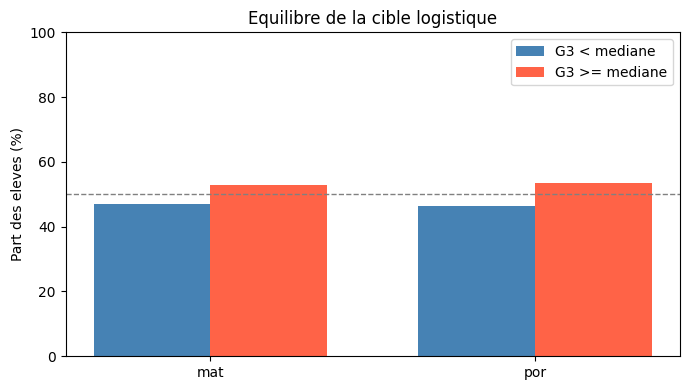

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(target_balance))
width = 0.36

ax.bar(x - width / 2, target_balance['low_or_equal_pct'], width, label='G3 < mediane', color='steelblue')
ax.bar(x + width / 2, target_balance['high_pct'], width, label='G3 >= mediane', color='tomato')
ax.axhline(50, color='gray', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(target_balance['dataset'])
ax.set_ylim(0, 100)
ax.set_ylabel('Part des eleves (%)')
ax.set_title('Equilibre de la cible logistique')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Variables quantitatives retenues

On garde les variables qui ne sont pas dominees par une seule modalite. Exemple : `Dalc` est exclue car environ 70% des eleves sont en modalite 1.

In [6]:
print('Variables retenues :')
print(', '.join(selected_predictors['selected_predictors']))

print('\nVariables exclues :')
print(', '.join(excluded_predictors['excluded_predictors']))

excluded_detail = screening[screening['variable'].isin(excluded_predictors['excluded_predictors'])]
display(excluded_detail[['dataset', 'variable', 'modal_value', 'modal_share', 'mean', 'std']].round(3))

Variables retenues :
age, Medu, Fedu, studytime, famrel, freetime, goout, Walc, health, absences

Variables exclues :
traveltime, failures, Dalc


,dataset,variable,modal_value,modal_share,mean,std
3,mat,traveltime,1,0.651,1.448,0.697
5,mat,failures,0,0.790,0.334,0.743
9,mat,Dalc,1,0.699,1.481,0.890
19,por,traveltime,1,0.564,1.569,0.748
21,por,failures,0,0.846,0.222,0.593
25,por,Dalc,1,0.695,1.502,0.924


## 5. Resultats des regressions

Deux versions sont comparees :

- `context_only` : variables socio-comportementales quantitatives equilibrees. Modele surtout interpretable.
- `with_G1_G2` : ajoute les notes precedentes `G1` et `G2`. Modele predictif principal.

In [7]:
cols = [
    'dataset', 'model', 'target', 'n_features', 'baseline_metric',
    'primary_metric', 'r2', 'balanced_accuracy', 'f1', 'roc_auc',
    'cv_accuracy_mean'
]
display(metrics[cols].round(3))

,dataset,model,target,n_features,baseline_metric,primary_metric,r2,balanced_accuracy,f1,roc_auc,cv_accuracy_mean
0,mat,linear_context_only,G3,10,3.691,3.471,0.122,NaN,NaN,NaN,NaN
1,mat,logistic_context_only,G3 >= median (11),10,0.529,0.555,NaN,0.555,0.569,0.560,0.582
2,mat,linear_with_G1_G2,G3,12,3.691,1.348,0.806,NaN,NaN,NaN,NaN
3,mat,logistic_with_G1_G2,G3 >= median (11),12,0.529,0.933,NaN,0.933,0.937,0.981,0.914
4,por,linear_context_only,G3,10,2.448,2.222,0.171,NaN,NaN,NaN,NaN
5,por,logistic_context_only,G3 >= median (12),10,0.538,0.667,NaN,0.665,0.689,0.738,0.666
6,por,linear_with_G1_G2,G3,12,2.448,0.758,0.876,NaN,NaN,NaN,NaN
7,por,logistic_with_G1_G2,G3 >= median (12),12,0.538,0.928,NaN,0.929,0.933,0.982,0.921


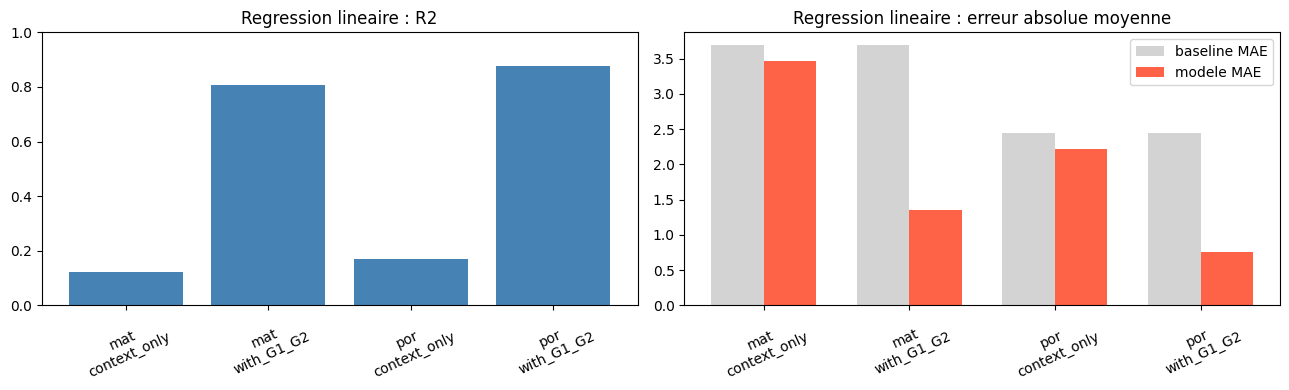

In [8]:
linear_metrics = metrics[metrics['model'].str.startswith('linear')].copy()
linear_metrics['label'] = linear_metrics['dataset'] + '\n' + linear_metrics['model'].str.replace('linear_', '', regex=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(linear_metrics['label'], linear_metrics['r2'], color='steelblue')
axes[0].set_title('Regression lineaire : R2')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=25)

x = np.arange(len(linear_metrics))
axes[1].bar(x - 0.18, linear_metrics['baseline_metric'], 0.36, label='baseline MAE', color='lightgray')
axes[1].bar(x + 0.18, linear_metrics['primary_metric'], 0.36, label='modele MAE', color='tomato')
axes[1].set_xticks(x)
axes[1].set_xticklabels(linear_metrics['label'], rotation=25)
axes[1].set_title('Regression lineaire : erreur absolue moyenne')
axes[1].legend()

plt.tight_layout()
plt.show()

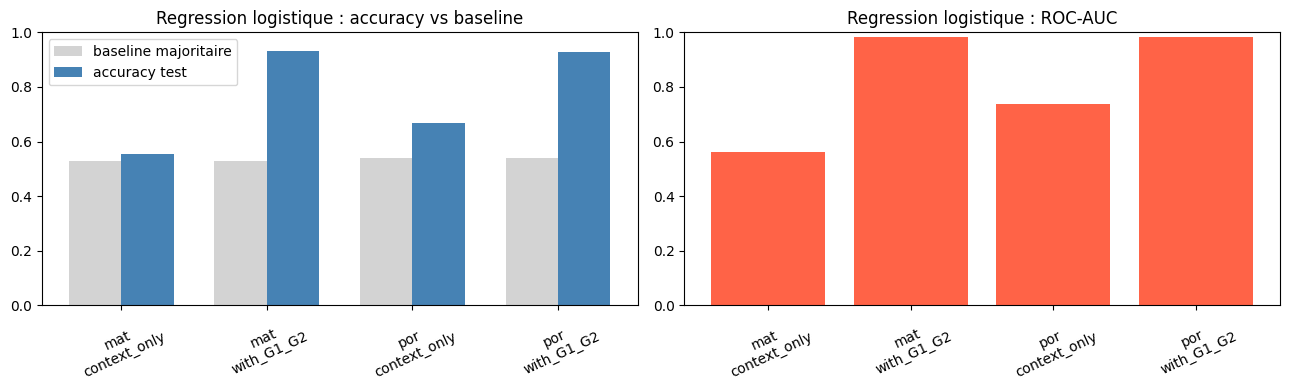

In [9]:
logit_metrics = metrics[metrics['model'].str.startswith('logistic')].copy()
logit_metrics['label'] = logit_metrics['dataset'] + '\n' + logit_metrics['model'].str.replace('logistic_', '', regex=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(logit_metrics))
axes[0].bar(x - 0.18, logit_metrics['baseline_metric'], 0.36, label='baseline majoritaire', color='lightgray')
axes[0].bar(x + 0.18, logit_metrics['primary_metric'], 0.36, label='accuracy test', color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(logit_metrics['label'], rotation=25)
axes[0].set_ylim(0, 1)
axes[0].set_title('Regression logistique : accuracy vs baseline')
axes[0].legend()

axes[1].bar(logit_metrics['label'], logit_metrics['roc_auc'], color='tomato')
axes[1].set_ylim(0, 1)
axes[1].set_title('Regression logistique : ROC-AUC')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

## 6. Coefficients des modeles

Les coefficients sont standardises : ils sont comparables car les variables ont ete centrees-reduites dans le pipeline.

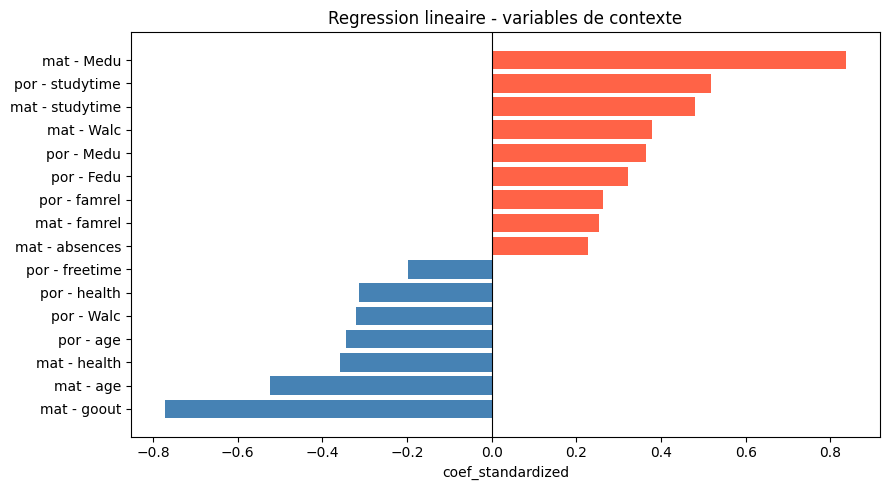

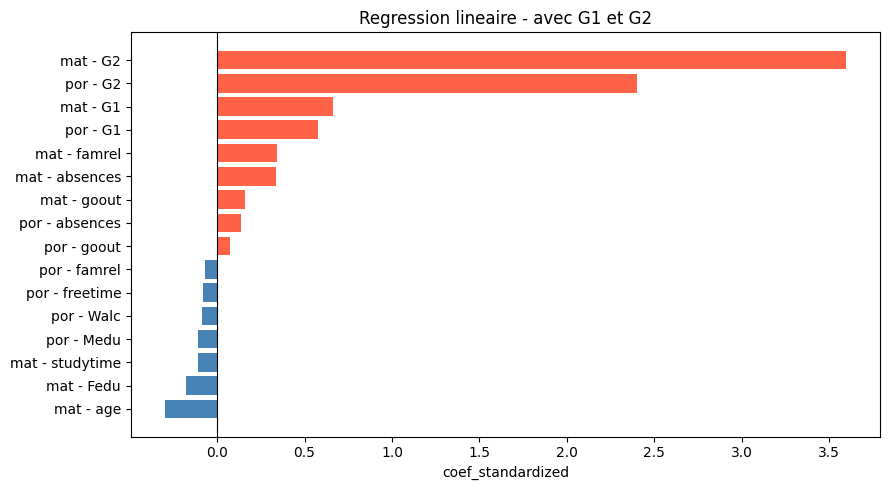

In [10]:
def plot_top_coefficients(df, model_name, title, value_col='coef_standardized', top_n=8):
    sub = df[df['model'] == model_name].copy()
    sub['abs_value'] = sub[value_col].abs()
    sub = (
        sub.sort_values(['dataset', 'abs_value'], ascending=[True, False])
           .groupby('dataset')
           .head(top_n)
           .copy()
    )
    sub['label'] = sub['dataset'] + ' - ' + sub['feature']
    sub = sub.sort_values(value_col)

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = np.where(sub[value_col] >= 0, 'tomato', 'steelblue')
    ax.barh(sub['label'], sub[value_col], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel(value_col)
    plt.tight_layout()
    plt.show()

plot_top_coefficients(linear_coef, 'linear_context_only', 'Regression lineaire - variables de contexte')
plot_top_coefficients(linear_coef, 'linear_with_G1_G2', 'Regression lineaire - avec G1 et G2')

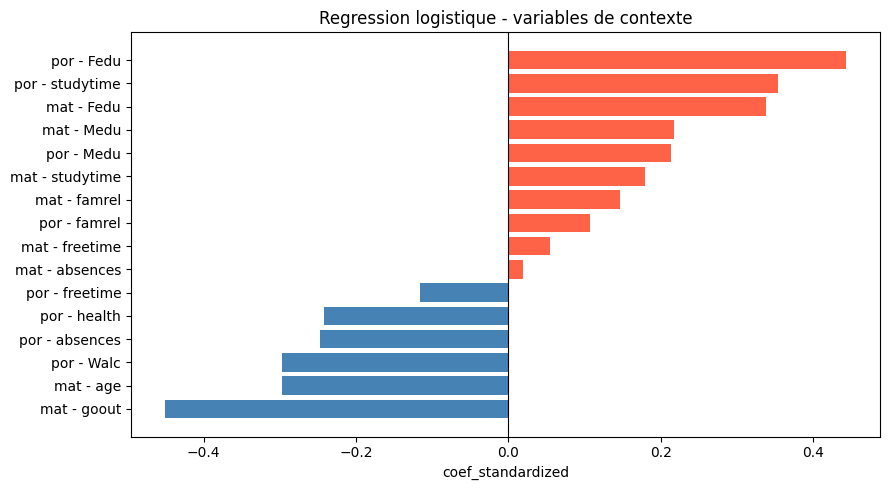

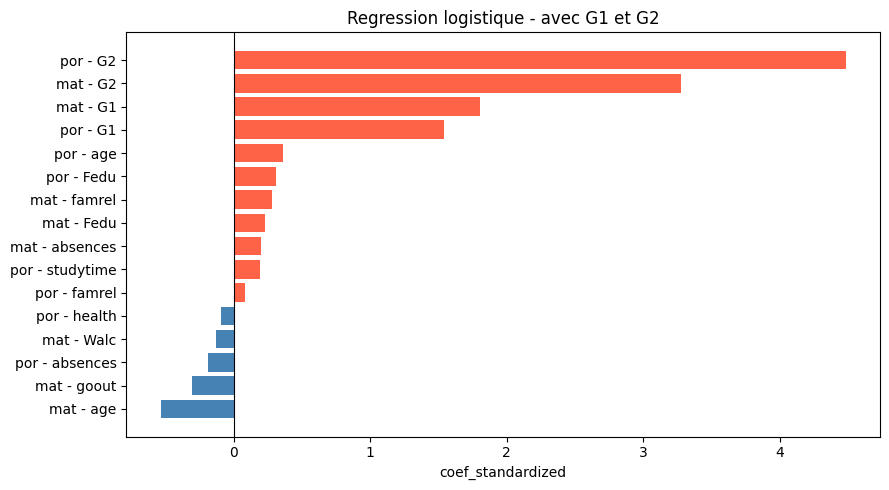

,dataset,model,feature,coef_standardized,odds_ratio
0,mat,logistic_context_only,goout,-0.451,0.637
1,mat,logistic_context_only,Fedu,0.338,1.402
2,mat,logistic_context_only,age,-0.297,0.743
3,mat,logistic_context_only,Medu,0.217,1.243
4,mat,logistic_context_only,studytime,0.179,1.196
5,mat,logistic_context_only,famrel,0.146,1.158
10,mat,logistic_with_G1_G2,G2,3.278,26.521
11,mat,logistic_with_G1_G2,G1,1.802,6.060
12,mat,logistic_with_G1_G2,age,-0.535,0.586
13,mat,logistic_with_G1_G2,goout,-0.306,0.736


In [11]:
plot_top_coefficients(logit_coef, 'logistic_context_only', 'Regression logistique - variables de contexte')
plot_top_coefficients(logit_coef, 'logistic_with_G1_G2', 'Regression logistique - avec G1 et G2')

display(
    logit_coef.groupby(['dataset', 'model'])
    .head(6)[['dataset', 'model', 'feature', 'coef_standardized', 'odds_ratio']]
    .round(3)
)

## Interpretation courte

Le modele `context_only` reste modeste, surtout en mathematiques : les variables sociales et comportementales seules expliquent peu la note finale. En portugais, le signal est plus net : l'education parentale et `studytime` sont positifs, tandis que `Walc` et `absences` reduisent la probabilite d'etre au-dessus de la mediane.

Avec `G1` et `G2`, les deux regressions deviennent tres performantes. `G2` est le predicteur dominant, puis `G1`, ce qui est coherent : la note finale suit fortement la trajectoire scolaire deja observee.